# Functions

In [1]:
import re
import os
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk

def parse_mr_filename(filename: str):
    """
    Extract region, center, and year from filenames like:
    - AB_1ABC118_MR.nii.gz
    - brain_1BA345_MR.nii.gz

    Rules:
    - Extract the part between the first and second underscore.
    - center = last letter of that segment
    - region = all letters before the center
    - year = 2023 if region is 'B' or 'P', otherwise 2025
    """
    # Get substring between first and second underscore
    match = re.search(r'^[^_]+_([^_]+)_', filename)
    if not match:
        raise ValueError(f"Filename format not recognized: {filename}")

    middle = match.group(1)

    # Extract letters only
    letters = re.findall(r'[A-Za-z]', middle)
    if not letters:
        raise ValueError(f"No letters found in middle segment of {filename}")

    center = letters[-1]
    region = ''.join(letters[:-1])

    # Year rule
    year = "2023" if region in ("B", "P") else "2025"

    center_year = center + "_" + year

    return region, center_year


def find_global_min_max(paths):
    """
    First step: find global min and max voxel values across all volumes.
    """
    global_min = None
    global_max = None

    for p in tqdm(paths):
        img = sitk.ReadImage(str(p))
        arr = sitk.GetArrayFromImage(img).astype(float)
        vmin = float(np.min(arr))
        vmax = float(np.max(arr))

        if global_min is None or vmin < global_min:
            global_min = vmin
        if global_max is None or vmax > global_max:
            global_max = vmax

    return global_min, global_max

def build_cdf_table(paths, min, max, n_points=200):
    """
    Second step: build a table with 200 columns going from global min to global max,
    each column containing the CDF value (percent of voxels <= threshold intensity)
    for each volume.

    Additional columns added:
    - min_value (float)
    - max_value (float)
    - nx, ny, nz (voxel dimensions)

    Returns
    -------
    table : np.ndarray (structured)
        One row per volume.
    thresholds : np.ndarray
        Intensity thresholds (same for all volumes).
    """

    # 1) Global min & max from first pass
    global_min, global_max = min, max

    # 2) Define intensity thresholds
    thresholds = np.linspace(global_min, global_max, n_points)

    # 3) Table dtype
    meta_fields = [
        ("filename", "U32"),
        ("region", "U16"),
        ("center_year", "U8"),

        ("min_value", "f4"),
        ("max_value", "f4"),

        ("nx", "i4"),
        ("ny", "i4"),
        ("nz", "i4"),

        ("n_voxels", "i8"),
    ]

    cdf_fields = [(f"cdf_{i:03d}", "f4") for i in range(n_points)]
    dtype = np.dtype(meta_fields + cdf_fields)

    records = []

    for p in tqdm(paths):
        p = Path(p)
        img = sitk.ReadImage(str(p))

        arr = sitk.GetArrayFromImage(img).astype(np.float32)
        flat = arr.ravel()
        n_voxels = flat.size

        # Volume shape (z, y, x)
        nz, ny, nx = arr.shape

        # Per-volume min/max
        vmin = float(np.min(arr))
        vmax = float(np.max(arr))

        # CDF
        flat_sorted = np.sort(flat)
        idx = np.searchsorted(flat_sorted, thresholds, side="right")
        cdf = idx.astype(np.float64) / float(n_voxels)

        region, center_year = parse_mr_filename(p.name)

        record = (
            p.name,
            region,
            center_year,

            vmin,
            vmax,

            nx,
            ny,
            nz,

            int(n_voxels),

            *cdf.astype(np.float32)
        )

        records.append(record)

    table = np.array(records, dtype=dtype)
    return table, thresholds

def reconstruct_global_histogram_from_table(table, thresholds, group_col=None):
    """
    Reconstruct histogram(s) of voxel values across volumes using only the CDF
    table and the thresholds.
    
    Automatically detects if data is masked (has n_masked_voxels field) and uses
    appropriate voxel counts for weighting.
    """
    # Extract CDF columns (ensure correct order)
    cdf_field_names = sorted(
        [name for name in table.dtype.names if name.startswith("cdf_")]
    )
    # Shape: (n_volumes, n_points)
    cdfs = np.vstack([table[name] for name in cdf_field_names]).T

    n_vols, n_points = cdfs.shape
    assert n_points == len(thresholds), "Thresholds length must match CDF points."

    # Use masked voxel count if available, otherwise use total voxels
    if "n_masked_voxels" in table.dtype.names:
        n_voxels_per_vol = table["n_masked_voxels"].astype(float)
        print("Using MASKED voxel counts for weighting")
    else:
        n_voxels_per_vol = table["n_voxels"].astype(float)
        print("Using TOTAL voxel counts for weighting")

    bin_edges = np.asarray(thresholds, dtype=float)

    # --- No grouping: original global aggregation ---
    if group_col is None:
        total_voxels = float(np.sum(n_voxels_per_vol))
        weights = n_voxels_per_vol / total_voxels  # sum to 1

        # Weighted global CDF
        global_cdf = np.sum(weights[:, None] * cdfs, axis=0)

        # Differences -> histogram probabilities
        hist_probs = np.diff(global_cdf)
        hist_probs = np.clip(hist_probs, 0.0, None)
        if hist_probs.sum() > 0:
            hist_probs /= hist_probs.sum()

        hist_counts = hist_probs * total_voxels
        return hist_counts, bin_edges

    # --- With grouping ---
    group_values = table[group_col]
    unique_groups = np.unique(group_values)

    all_hist_counts = []

    for g in unique_groups:
        mask = (group_values == g)
        if not np.any(mask):
            continue

        # Subset of volumes in this group
        cdfs_g = cdfs[mask]
        n_voxels_g = n_voxels_per_vol[mask]

        total_voxels_g = float(np.sum(n_voxels_g))
        if total_voxels_g == 0:
            all_hist_counts.append(np.zeros(len(thresholds) - 1, dtype=float))
            continue

        weights_g = n_voxels_g / total_voxels_g

        # Weighted CDF for this group
        global_cdf_g = np.sum(weights_g[:, None] * cdfs_g, axis=0)

        # Differences -> histogram probabilities
        hist_probs_g = np.diff(global_cdf_g)
        hist_probs_g = np.clip(hist_probs_g, 0.0, None)
        if hist_probs_g.sum() > 0:
            hist_probs_g /= hist_probs_g.sum()

        # Convert to counts for this group's total voxels
        hist_counts_g = hist_probs_g * total_voxels_g
        all_hist_counts.append(hist_counts_g)

    hist_counts = np.vstack(all_hist_counts)
    return hist_counts, bin_edges, unique_groups


def plot_density_line(
    hist_counts,
    bin_edges,
    title="Global Voxel Intensity Density",
    remove_mode=False,
    labels=None,
):
    """
    Plot one or more histograms as continuous densities (line plot).

    Parameters
    ----------
    hist_counts : np.ndarray
        - shape (n_bins,) for a single histogram
        - shape (n_groups, n_bins) for multiple histograms
    bin_edges : np.ndarray
        Bin edges, shape (n_bins+1,).
    title : str
        Plot title.
    remove_mode : bool
        If True, sets the highest density value to 0 for each line.
    labels : list of str or None
        Labels for each line (for legend). Length must be n_groups if provided.
    """
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    if hist_counts.ndim == 1:
        hist_counts = hist_counts[None, :]  # shape -> (1, n_bins)

    n_groups, n_bins = hist_counts.shape

    # Use bin centers for plotting
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_widths = np.diff(bin_edges)

    if labels is None:
        labels = [f"Group {i}" for i in range(n_groups)]

    plt.figure(figsize=(10, 5))

    for i in range(n_groups):
        counts = hist_counts[i]
        total_count = counts.sum()

        if total_count == 0:
            # Skip empty histogram
            continue

        densities = counts / (total_count * bin_widths)

        if remove_mode:
            max_idx = np.argmax(densities)
            counts[max_idx] = np.nan
            densities[max_idx] = np.nan

        plt.plot(bin_centers, densities, linewidth=2, label=str(labels[i]))

    final_title = title
    if remove_mode:
        final_title += " (mode set to 0 for visibility)"

    plt.xlabel("Intensity")
    plt.ylabel("Density")
    plt.title(final_title)
    if n_groups > 1:
        plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_hist_outline(
    hist_counts,
    bin_edges,
    title="Global Voxel Intensity Histogram",
    remove_mode=False,
    labels=None,
    log_scale=False,
):

    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    # Ensure (n_groups, n_bins)
    if hist_counts.ndim == 1:
        hist_counts = hist_counts[None, :]

    n_groups, n_bins = hist_counts.shape

    if labels is None:
        labels = [f"Group {i}" for i in range(n_groups)]

    # Global total
    global_total = hist_counts.sum()

    plt.figure(figsize=(10, 5))

    for i in range(n_groups):
        counts = hist_counts[i].astype(float)

        if counts.sum() == 0:
            continue

        # Reweight to global total
        if global_total > 0:
            counts = counts * (global_total / counts.sum())

        # Optionally remove mode
        if remove_mode and np.any(counts > 0):
            counts[np.argmax(counts)] = 0.0

        color = f"C{i % 10}"

        # ---- Build closed step-outline coordinates ----
        # x:  [left_edge, all_edges..., right_edge]
        # y:  [0, counts..., last_count, 0]
        x_step = np.r_[bin_edges[0], bin_edges, bin_edges[-1]]
        y_step = np.r_[0.0, counts, counts[-1], 0.0]

        # ---- Step outline (now with full left & right edges) ----
        plt.step(
            x_step,
            y_step,
            where="post",
            color=color,
            linewidth=2,
            label=labels[i],
        )

        # ---- Transparent background fill matching the outline ----
        plt.fill_between(
            x_step,
            y_step,
            step="post",
            color=color,
            alpha=0.15,   # adjust transparency here
        )

    # Titles and labels
    final_title = title + (" (mode set to 0 for visibility)" if remove_mode else "")
    plt.title("[LOG-Scale] " + final_title if log_scale else final_title)
    plt.xlabel("Intensity")
    plt.ylabel("Count (log scale)" if log_scale else "Count")

    if log_scale:
        plt.yscale("log")

    if n_groups > 1:
        plt.legend()

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

def percentile_table_from_hist(
    hist_counts,
    bin_edges,
    labels,
    percentiles=(90, 95, 99),
):
    """
    Compute percentiles from histogram counts for each row.

    Parameters
    ----------
    hist_counts : np.ndarray
        - shape (n_bins,) for a single histogram
        - shape (n_rows, n_bins) for multiple histograms
    bin_edges : np.ndarray
        Bin edges, shape (n_bins + 1,).
    percentiles : iterable of float
        Percentiles to compute, in [0, 100]. Default: (99, 95).

    Returns
    -------
    table : np.ndarray (structured)
        Structured array with one row per histogram and one column per percentile.
        Column names are "pXX" where XX is the percentile integer, e.g. "p99".
    """
    hist_counts = np.asarray(hist_counts, dtype=float)
    bin_edges = np.asarray(bin_edges, dtype=float)

    # Ensure 2D: (n_rows, n_bins)
    if hist_counts.ndim == 1:
        hist_counts = hist_counts[None, :]

    n_rows, n_bins = hist_counts.shape
    assert bin_edges.shape[0] == n_bins + 1, "bin_edges must be length n_bins + 1."

    # Use bin centers as representative intensity values for interpolation
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    perc = np.asarray(percentiles, dtype=float)
    probs = perc / 100.0  # convert to [0,1]

    # Build a structured dtype: ('p99','f8'), ('p98','f8'), ...
    dtype = [(f"p{int(p)}", "f8") for p in percentiles]
    out = np.zeros(n_rows, dtype=dtype)

    for i in range(n_rows):
        counts = hist_counts[i]
        total = counts.sum()

        if total <= 0:
            # No data -> NaNs
            for name, _ in dtype:
                out[name][i] = np.nan
            continue

        pdf = counts / total
        cdf = np.cumsum(pdf)

        for p_val, q, (name, _) in zip(percentiles, probs, dtype):
            # Find first bin where CDF >= q
            idx = np.searchsorted(cdf, q)

            # Handle edges
            if idx == 0:
                xq = bin_centers[0]
            elif idx >= len(bin_centers):
                xq = bin_centers[-1]
            else:
                # Linear interpolation within the bin between bin_centers[idx-1] and bin_centers[idx]
                cdf_lo = cdf[idx - 1]
                cdf_hi = cdf[idx]
                x_lo = bin_centers[idx - 1]
                x_hi = bin_centers[idx]

                if cdf_hi == cdf_lo:
                    t = 0.0
                else:
                    t = (q - cdf_lo) / (cdf_hi - cdf_lo)

                xq = x_lo + t * (x_hi - x_lo)

            out[name][i] = xq

    df = pd.DataFrame(out)
    df.insert(0, "group", labels)

    return df

def plot_filtered_bodyregion(table, thresholds, region_abbrev):
    regions = {
        "AB": "Abdomen",
        "B": "Brain",
        "HN": "Head-and-Neck",
        "P": "Pelvis",
        "TH": "Thorax"
    }

    # filter data
    table_filtered = table.copy()
    table_filtered = table_filtered[table_filtered["region"]==region_abbrev]

    # Step 3: reconstruct global histogram by center_year
    hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table_filtered, thresholds, group_col="center_year")
    percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels=groups.astype(str))

    # Step 4: Plot
    title=f"Voxel Intensity Density by Treatment Center for {regions[region_abbrev]}"
    # plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
    # plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)
    print(percentile_table)

    # Step 5: Plot histogram
    hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table_filtered, thresholds, group_col="center_year")
    title = title.replace("Density", "Histogram, reweighted")
    plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
    plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False, log_scale=True)
    plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)

def find_global_min_max_masked(vol_paths, mask_paths):
    """Find global min and max voxel values across all volumes using masks."""
    global_min = None
    global_max = None

    for vol_p, mask_p in tqdm(zip(vol_paths, mask_paths), total=len(vol_paths)):
        vol_img = sitk.ReadImage(str(vol_p))
        mask_img = sitk.ReadImage(str(mask_p))
        
        vol_arr = sitk.GetArrayFromImage(vol_img).astype(float)
        mask_arr = sitk.GetArrayFromImage(mask_img)
        
        # Check shape compatibility
        if vol_arr.shape != mask_arr.shape:
            print(f"Warning: Shape mismatch for {Path(vol_p).name}: vol={vol_arr.shape}, mask={mask_arr.shape}")
            continue
        
        # Only consider masked voxels
        masked_voxels = vol_arr[mask_arr > 0]
        
        if masked_voxels.size == 0:
            print(f"Warning: Empty mask for {Path(vol_p).name}")
            continue
            
        vmin = float(np.min(masked_voxels))
        vmax = float(np.max(masked_voxels))

        if global_min is None or vmin < global_min:
            global_min = vmin
        if global_max is None or vmax > global_max:
            global_max = vmax

    return global_min, global_max


def build_cdf_table_masked(vol_paths, mask_paths, min, max, n_points=200):
    """Build CDF table using only masked voxels."""
    global_min, global_max = min, max
    thresholds = np.linspace(global_min, global_max, n_points)

    meta_fields = [
        ("filename", "U32"),
        ("region", "U16"),
        ("center_year", "U8"),
        ("min_value", "f4"),
        ("max_value", "f4"),
        ("nx", "i4"),
        ("ny", "i4"),
        ("nz", "i4"),
        ("n_voxels", "i8"),
        ("n_masked_voxels", "i8"),
    ]

    cdf_fields = [(f"cdf_{i:03d}", "f4") for i in range(n_points)]
    dtype = np.dtype(meta_fields + cdf_fields)
    records = []

    for vol_p, mask_p in tqdm(zip(vol_paths, mask_paths), total=len(vol_paths)):
        vol_p = Path(vol_p)
        
        vol_img = sitk.ReadImage(str(vol_p))
        mask_img = sitk.ReadImage(str(mask_p))
        
        vol_arr = sitk.GetArrayFromImage(vol_img).astype(np.float32)
        mask_arr = sitk.GetArrayFromImage(mask_img)
        
        # Check shape compatibility
        if vol_arr.shape != mask_arr.shape:
            print(f"Warning: Shape mismatch for {vol_p.name}, skipping")
            continue
        
        # Volume dimensions
        nz, ny, nx = vol_arr.shape
        n_total_voxels = vol_arr.size
        
        # Get only masked voxels
        masked_voxels = vol_arr[mask_arr > 0]
        n_masked_voxels = masked_voxels.size
        
        if n_masked_voxels == 0:
            print(f"Warning: Empty mask for {vol_p.name}, skipping")
            continue
        
        # Per-volume min/max on masked voxels only
        vmin = float(np.min(masked_voxels))
        vmax = float(np.max(masked_voxels))
        
        # CDF on masked voxels
        flat_sorted = np.sort(masked_voxels)
        idx = np.searchsorted(flat_sorted, thresholds, side="right")
        cdf = idx.astype(np.float64) / float(n_masked_voxels)
        
        region, center_year = parse_mr_filename(vol_p.name)
        
        record = (
            vol_p.name,
            region,
            center_year,
            vmin,
            vmax,
            nx, ny, nz,
            int(n_total_voxels),
            int(n_masked_voxels),
            *cdf.astype(np.float32)
        )
        records.append(record)

    table = np.array(records, dtype=dtype)
    return table, thresholds


# Data Loading

In [6]:
import os
os.getcwd()


'/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/2resampledNifti'

In [3]:
# find filenames per data split (to work in 2resampledNifti)
datadir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/2resampledNifti"
outdir = "/home/user/mfrei/projects/fullbody-sCT/preprocessing/preprocessing_synthrad/analysis/2ndExperiment"
os.chdir(outdir)
split = pd.read_csv("../../splits_manifest.csv")
split["folder"] = split["example_path"].str.split("/").str[-1]
split["filename"] = split["folder"] + "_MR_cp256.nii.gz"
split["path"] = split["folder"] + "/MR/" + split["filename"]

# Add mask paths
split["mask_filename"] = split["folder"] + "_mask_from_CT_treshold_cp256.nii.gz"
split["mask_path"] = split["folder"] + "/new_masks/" + split["mask_filename"]

all_files = split["path"].tolist()
all_mask_files = split["mask_path"].tolist()

# # find filenames per data split (to work in 3resampledNiftiNyulReady)
# datadir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/3resampledNiftiNyulReady/MR"
# os.chdir(datadir)
# split = pd.read_csv("../../splits_manifest.csv")
# split["filename"] = split["example_path"].str.split("/").str[-1]
# split["filename"] = split["filename"].str.split("-").str[0]
# split["filename"] = split["filename"] + "_MR.nii.gz"
# all_files = split["filename"].tolist()

# split according to train/val/test
train_files = split[split["split"]=="train"]
train_files = train_files["filename"].tolist()

test_files = split[split["split"]=="test"]
test_files = test_files["filename"].tolist()

In [16]:
files = all_files

# Step 1: Find global min and max intensity values
os.chdir(datadir)

#min, max = find_global_min_max_masked(files, all_mask_files)
#or 
# min, max = find_global_min_max(files)

#print(f"min={round(min, 5)}\nmax={round(max, 5)}")

In [13]:
os.getcwd()


'/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/2resampledNifti'

In [14]:
# Step 2: build the CDF table with masks
# min, max = 0, 1  # or use the min/max from Step 1
# print(f"min={round(min, 5)}\nmax={round(max, 5)}")

# Masked CDF table
# table, thresholds = build_cdf_table_masked(files, all_mask_files, min, max, n_points=100)
# os.chdir(outdir)
# np.savez("histogram_data_MASKED.npz", table=table, thresholds=thresholds)

# Unmasked CDF table
# table, thresholds = build_cdf_table(files, min, max, n_points=100)
# os.chdir(outdir)
# np.savez("histogram_data_UNMASKED.npz", table=table, thresholds=thresholds)



#To load the masked data later:
datadir = "/home/user/mfrei/projects/fullbody-sCT/preprocessing/preprocessing_synthrad/analysis/2ndExperiment"
os.chdir(datadir)
# data = np.load("histogram_data_MASKED.npz")
data = np.load("histogram_data_UNMASKED.npz")

table, thresholds = data["table"], data["thresholds"]

In [18]:
# =============================================================================
# STEP 1A: ALL VOXELS (including background zeros)
# =============================================================================
datadir = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/2resampledNifti"
os.chdir(datadir)
print("Processing ALL voxels (including background)...")
min_all, max_all = find_global_min_max(all_files)
print(f"ALL VOXELS - min={round(min_all, 5)}, max={round(max_all, 5)}")

# Build CDF table for ALL voxels
table_all, thresholds_all = build_cdf_table(all_files, min_all, max_all, n_points=100)
os.chdir(outdir)
np.savez("histogram_data_ALL_VOXELS.npz", table=table_all, thresholds=thresholds_all)

Processing ALL voxels (including background)...


100%|██████████| 938/938 [04:23<00:00,  3.56it/s]


ALL VOXELS - min=0.0, max=5503.0


100%|██████████| 938/938 [07:40<00:00,  2.04it/s]  


In [19]:
# =============================================================================
# STEP 1B: MASKED VOXELS ONLY (excluding background)
# =============================================================================
os.chdir(datadir)
print("\nProcessing MASKED voxels only (excluding background)...")
min_masked, max_masked = find_global_min_max_masked(all_files, all_mask_files)
print(f"MASKED VOXELS - min={round(min_masked, 5)}, max={round(max_masked, 5)}")

# Build CDF table for MASKED voxels only
table_masked, thresholds_masked = build_cdf_table_masked(all_files, all_mask_files, min_masked, max_masked, n_points=100)
os.chdir(outdir)
np.savez("histogram_data_MASKED_VOXELS.npz", table=table_masked, thresholds=thresholds_masked)



Processing MASKED voxels only (excluding background)...


100%|██████████| 938/938 [03:51<00:00,  4.05it/s]  


MASKED VOXELS - min=0.0, max=5503.0


100%|██████████| 938/938 [06:01<00:00,  2.60it/s]  


In [20]:
# =============================================================================
# STEP 2: LOAD AND COMPARE BOTH DATASETS
# =============================================================================
os.chdir(outdir)

# Load ALL voxels data
data_all = np.load("histogram_data_ALL_VOXELS.npz")
table_all, thresholds_all = data_all["table"], data_all["thresholds"]

# Load MASKED voxels data
data_masked = np.load("histogram_data_MASKED_VOXELS.npz")
table_masked, thresholds_masked = data_masked["table"], data_masked["thresholds"]

print(f"\nALL VOXELS: intensity range [{thresholds_all[0]:.3f}, {thresholds_all[-1]:.3f}]")
print(f"MASKED VOXELS: intensity range [{thresholds_masked[0]:.3f}, {thresholds_masked[-1]:.3f}]")



ALL VOXELS: intensity range [0.000, 5503.000]
MASKED VOXELS: intensity range [0.000, 5503.000]


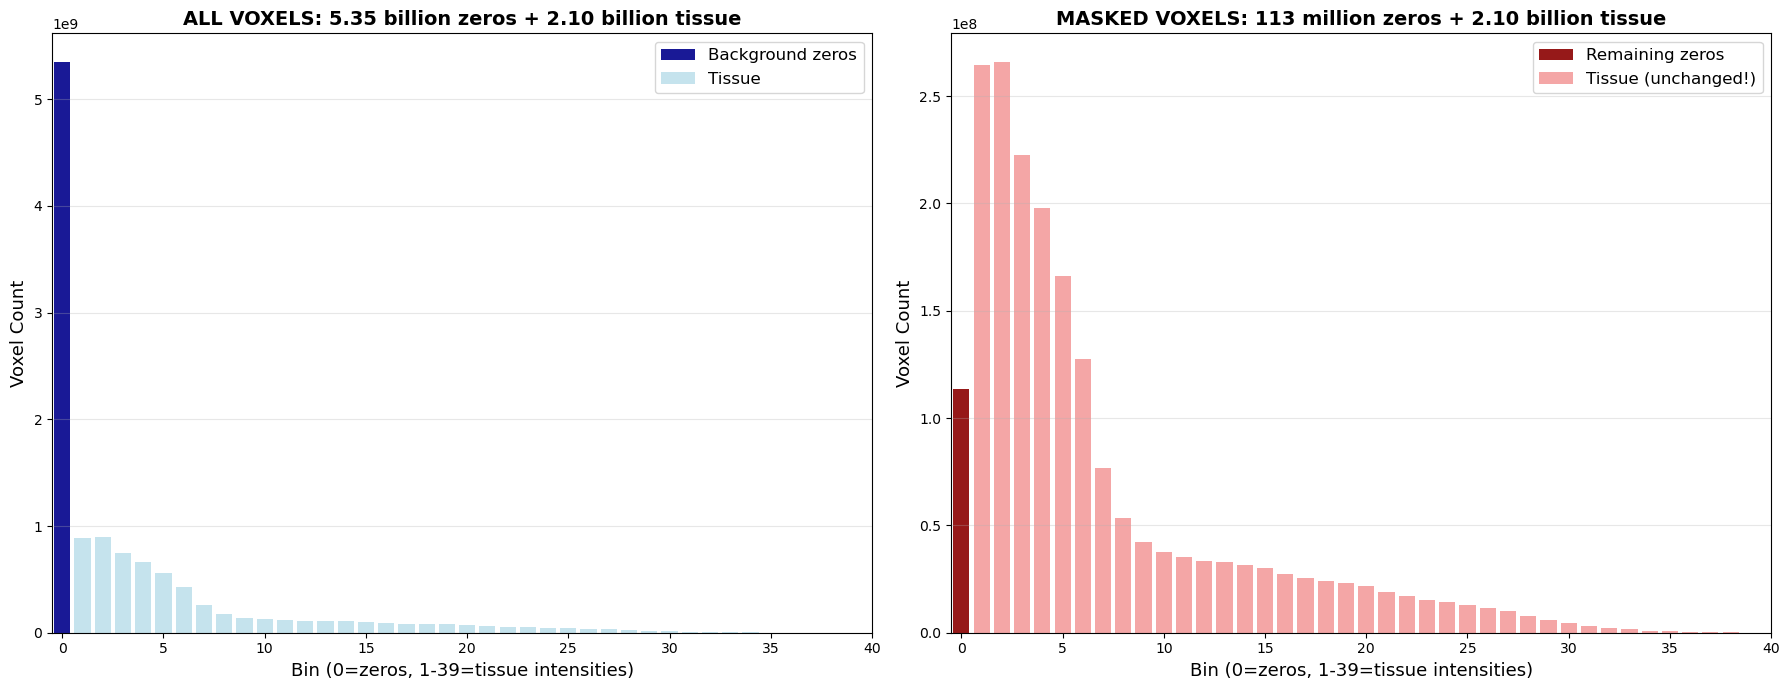


THE KEY DIFFERENCE:
• Background zeros:  5,350,911,054 →    113,646,512  (47x reduction)
• Tissue voxels:     2,101,908,402 →  2,101,908,401  (1.0x = identical)

The mask removes 98% of background zeros but preserves ALL tissue!


In [48]:
# =============================================================================
# TWO PLOTS SHOWING THE DIFFERENCE: Zeros vs Tissue separated
# =============================================================================

# Calculate exact zeros (already done in previous cells, but recalculating for clarity)
n_exact_zeros_all = np.sum(table_all['n_voxels'] * table_all['cdf_000'])
n_nonzeros_all = hist_counts_all.sum() - n_exact_zeros_all

n_exact_zeros_masked = np.sum(table_masked['n_masked_voxels'] * table_masked['cdf_000'])
n_nonzeros_masked = hist_counts_masked.sum() - n_exact_zeros_masked

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ============= LEFT: ALL VOXELS (zeros + tissue) =============
x_pos = np.arange(40)  # Show first 40 bins
width = 0.8

# Separate bar for zeros
axes[0].bar(0, n_exact_zeros_all, width=width, color='darkblue', alpha=0.9, label='Background zeros')
# Tissue bins
axes[0].bar(x_pos[1:], hist_counts_all[1:40], width=width, color='lightblue', alpha=0.7, label='Tissue')

axes[0].set_xlabel('Bin (0=zeros, 1-39=tissue intensities)', fontsize=13)
axes[0].set_ylabel('Voxel Count', fontsize=13)
axes[0].set_title('ALL VOXELS: 5.35 billion zeros + 2.10 billion tissue', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=12, loc='upper right')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_xlim(-0.5, 40)



# ============= RIGHT: MASKED VOXELS (zeros mostly removed) =============
# Separate bar for zeros
axes[1].bar(0, n_exact_zeros_masked, width=width, color='darkred', alpha=0.9, label='Remaining zeros')
# Tissue bins (identical to ALL!)
axes[1].bar(x_pos[1:], hist_counts_masked[1:40], width=width, color='lightcoral', alpha=0.7, label='Tissue (unchanged!)')

axes[1].set_xlabel('Bin (0=zeros, 1-39=tissue intensities)', fontsize=13)
axes[1].set_ylabel('Voxel Count', fontsize=13)
axes[1].set_title('MASKED VOXELS: 113 million zeros + 2.10 billion tissue', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_xlim(-0.5, 40)


plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("THE KEY DIFFERENCE:")
print("="*80)
print(f"• Background zeros: {n_exact_zeros_all:>14,.0f} → {n_exact_zeros_masked:>14,.0f}  (47x reduction)")
print(f"• Tissue voxels:    {n_nonzeros_all:>14,.0f} → {n_nonzeros_masked:>14,.0f}  (1.0x = identical)")
print("\nThe mask removes 98% of background zeros but preserves ALL tissue!")
print("="*80)

# Plots

## General

### Overall

Using TOTAL voxel counts for weighting
  group         p90          p95          p99
0   All  919.512512  1190.520178  1569.876268
Using TOTAL voxel counts for weighting


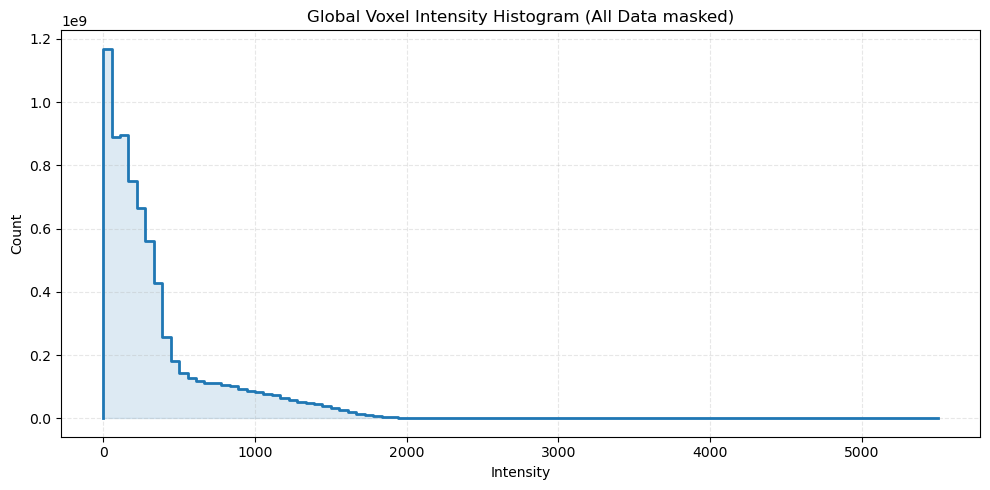

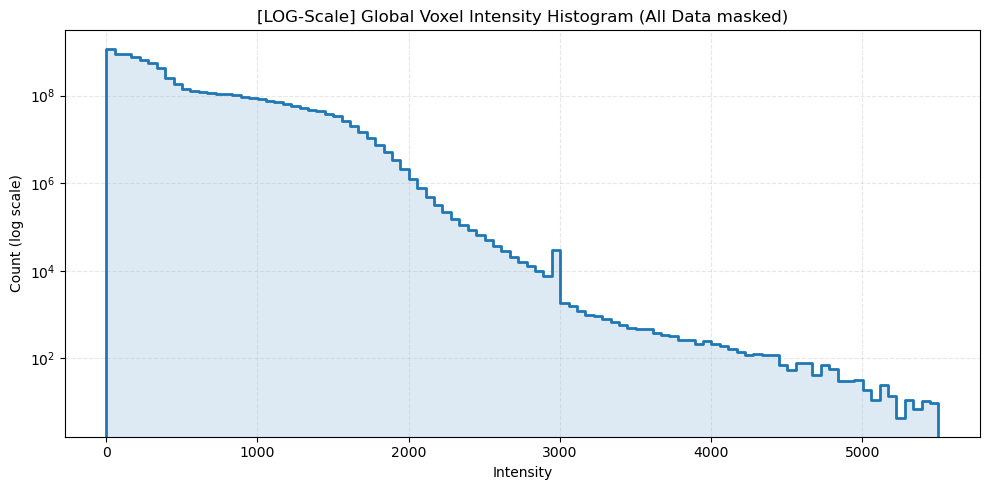

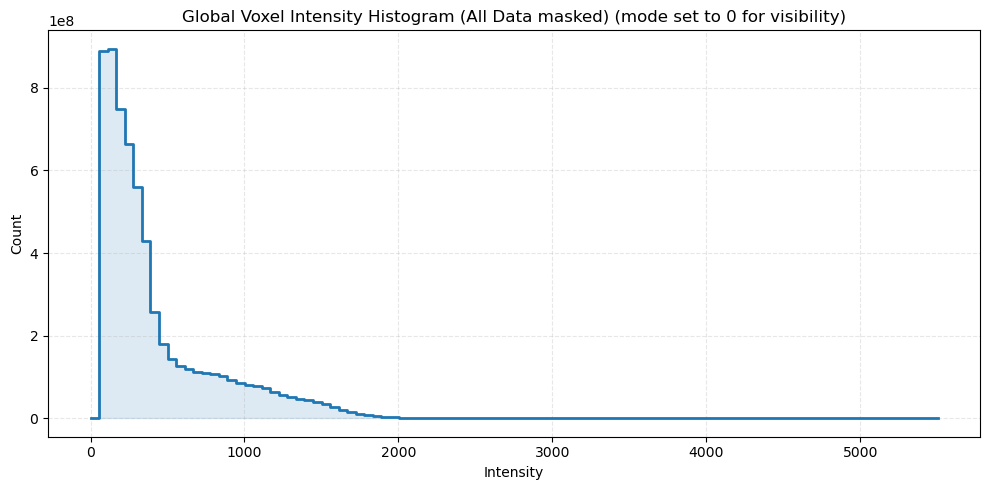

In [31]:
# Step 3: reconstruct global histogram on all data
hist_counts, bin_edges = reconstruct_global_histogram_from_table(table, thresholds, group_col=None)
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels="All")
title="Global Voxel Intensity Density (All Data masked)"
# plot_density_line(hist_counts, bin_edges, title=title, labels="All", remove_mode=False)
# plot_density_line(hist_counts, bin_edges, title=title, labels="All", remove_mode=True)
print(percentile_table)

# Step 5: Plot histogram
hist_counts, bin_edges = reconstruct_global_histogram_from_table(table, thresholds, group_col=None)
title = title.replace("Density", "Histogram")
plot_hist_outline(hist_counts, bin_edges, title=title, labels="All", remove_mode=False)
plot_hist_outline(hist_counts, bin_edges, title=title, labels="All", remove_mode=False, log_scale=True)
plot_hist_outline(hist_counts, bin_edges, title=title, labels="All", remove_mode=True)

### By Treatment Center (all Body Regions)

Using TOTAL voxel counts for weighting
    group          p90          p95          p99
0  A_2023  1169.714201  1392.500012  1747.246246
1  A_2025  1220.032316  1399.180156  1617.353958
2  B_2023   384.553730   448.258700   575.687955
3  B_2025   242.297120   300.488763   410.069976
4  C_2023   361.180001   466.579469   721.205479
5  C_2025   766.295561  1163.599609  1520.735075
6  D_2025   400.064939   455.354624   590.124889
Using TOTAL voxel counts for weighting


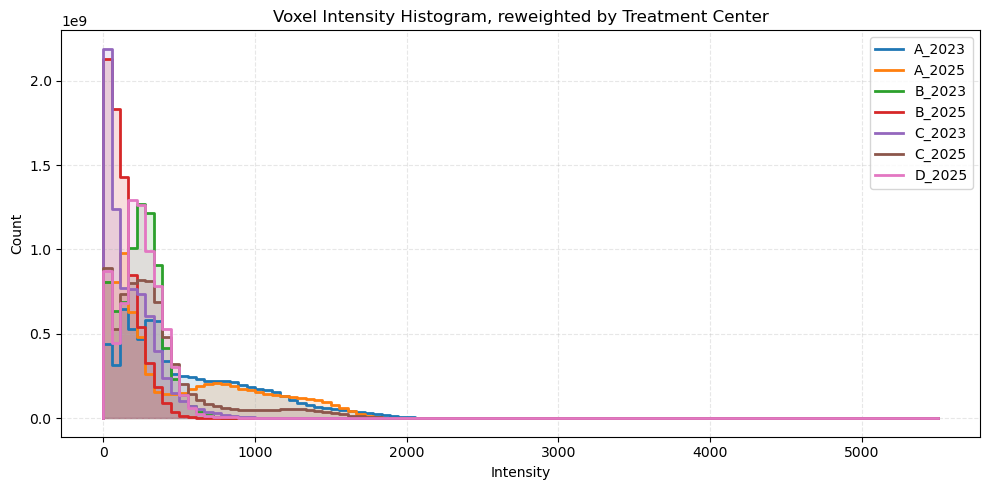

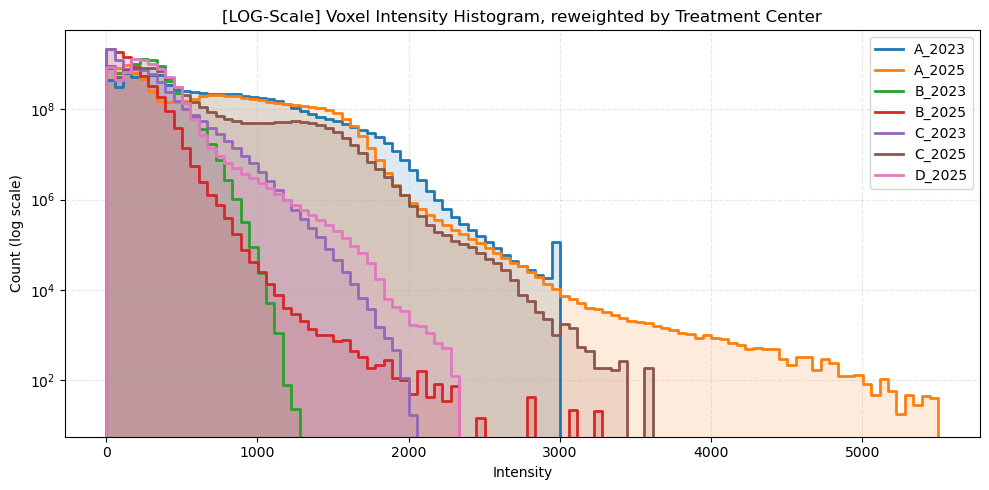

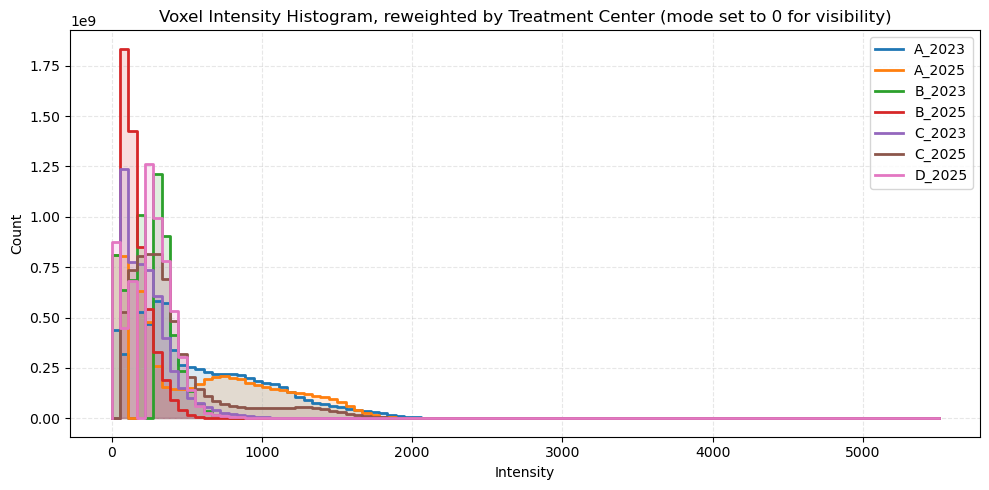

In [32]:
# Step 3: reconstruct global histogram by center_year
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="center_year")
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels=groups.astype(str))

# Step 4: Plot
title="Voxel Intensity Density by Treatment Center"
# plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
# plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)
print(percentile_table)

# Step 5: Plot histogram
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="center_year")
title = title.replace("Density", "Histogram, reweighted")
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False, log_scale=True)
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)

### By Body Region (all centers)

  group          p90          p95          p99
0    AB  1047.433110  1306.389540  1573.381003
1     B   956.597282  1173.604342  1642.209796
2    HN   650.538576   931.331930  1325.946255
3     P   845.673588  1161.077209  1598.351622
4    TH  1080.687537  1342.191160  1583.995283


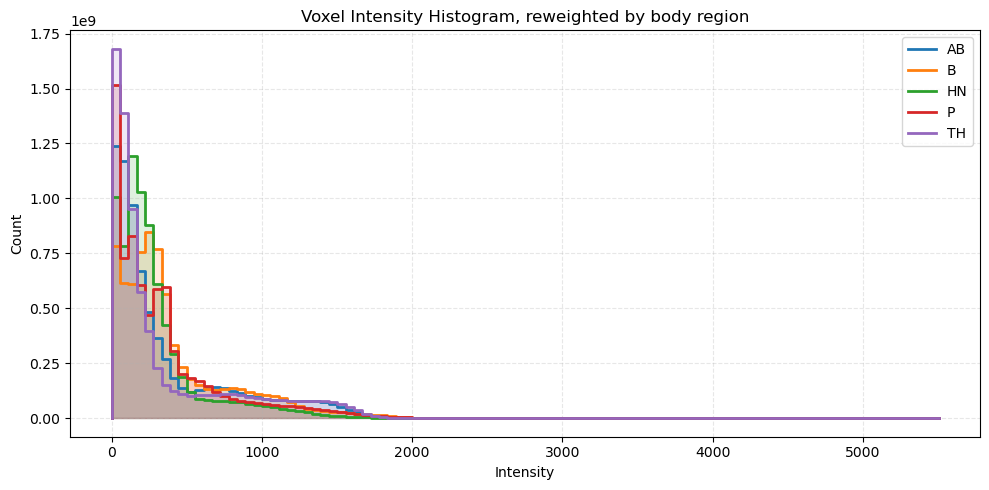

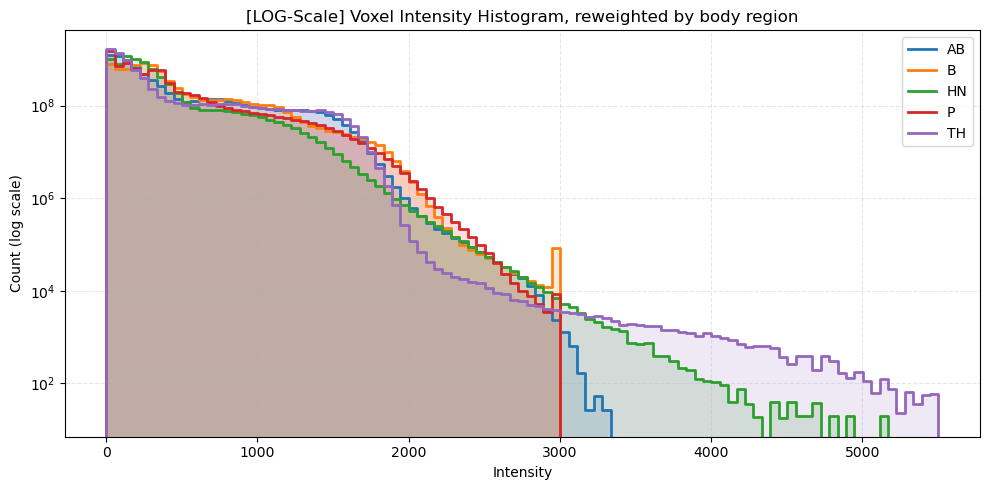

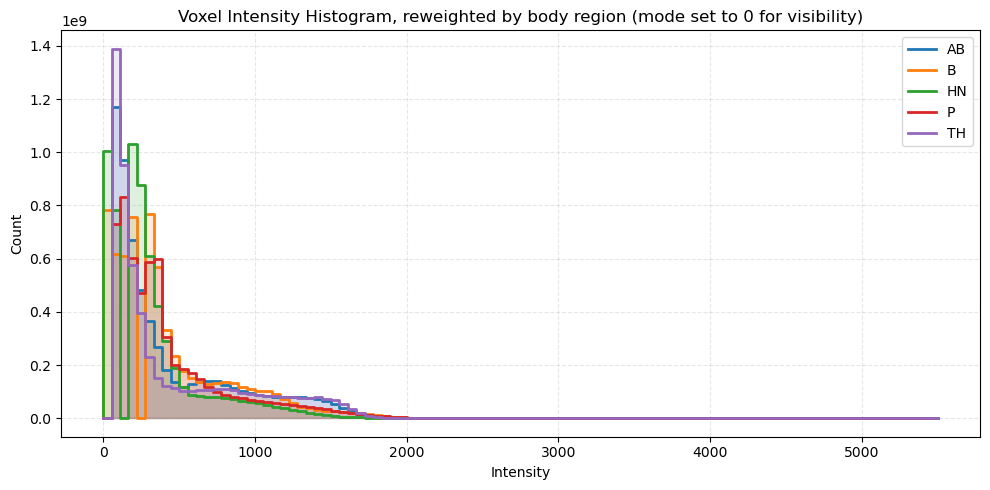

In [30]:
# Step 3: reconstruct global histogram by bodyregion
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="region")
percentile_table = percentile_table_from_hist(hist_counts, bin_edges, labels=groups.astype(str))

# Step 4: Plot
title="Voxel Intensity Density by body region"
# plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
# plot_density_line(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)
print(percentile_table)

# Step 5: Plot histogram
hist_counts, bin_edges, groups = reconstruct_global_histogram_from_table(table, thresholds, group_col="region")
title = title.replace("Density", "Histogram, reweighted")
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False)
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=False, log_scale=True)
plot_hist_outline(hist_counts, bin_edges, title=title, labels=groups.astype(str), remove_mode=True)

## By Body Region

### Abdomen by Treatment Center

    group       p90       p95       p99
0  A_2025  0.824574  0.893152  0.986528
1  B_2025  0.620497  0.784132  0.985819
2  C_2025  0.769462  0.855991  0.985979


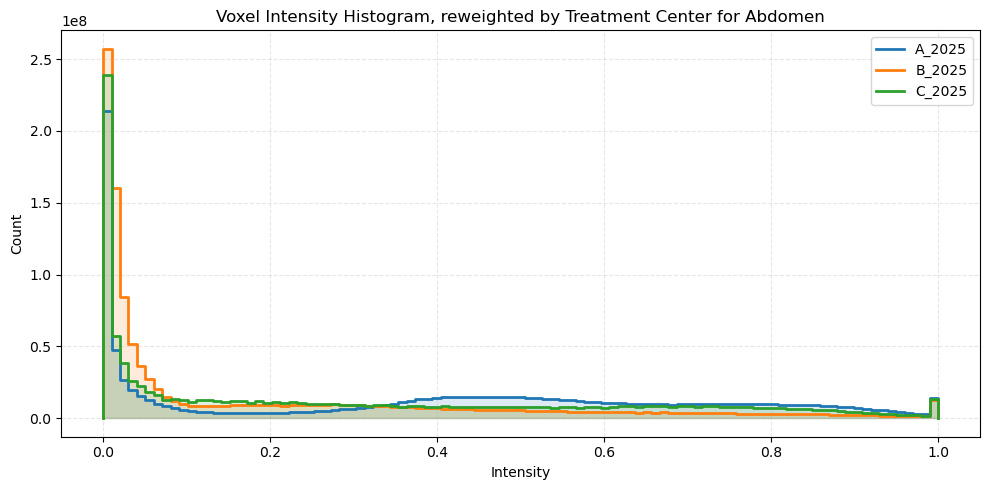

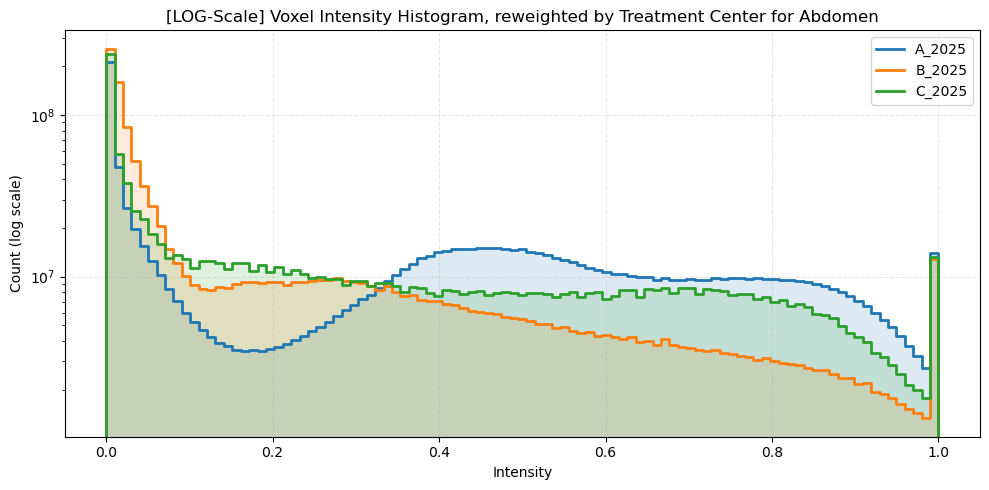

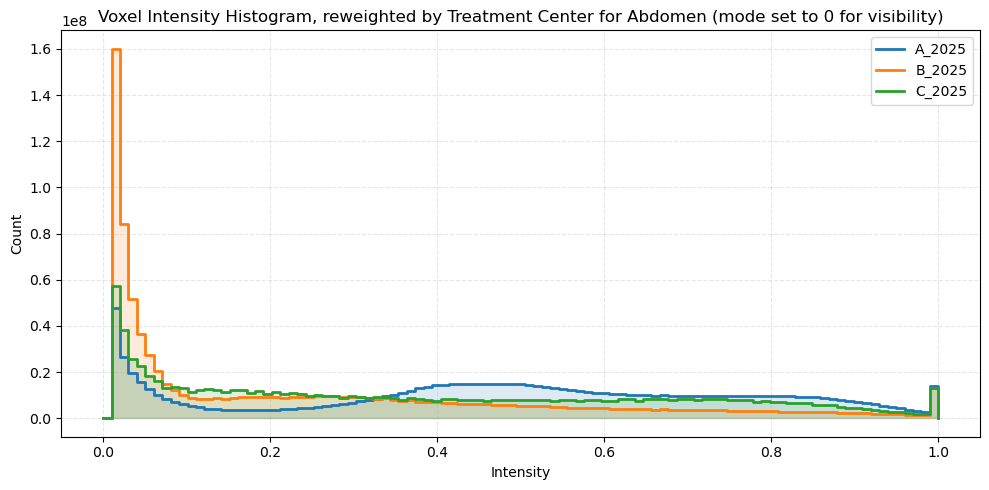

In [8]:
plot_filtered_bodyregion(table, thresholds, "AB")

### Brain by Treatment Center

    group       p90       p95       p99
0  A_2023  0.697399  0.824346  0.986238
1  B_2023  0.648363  0.749405  0.985629
2  C_2023  0.619227  0.741074  0.985581


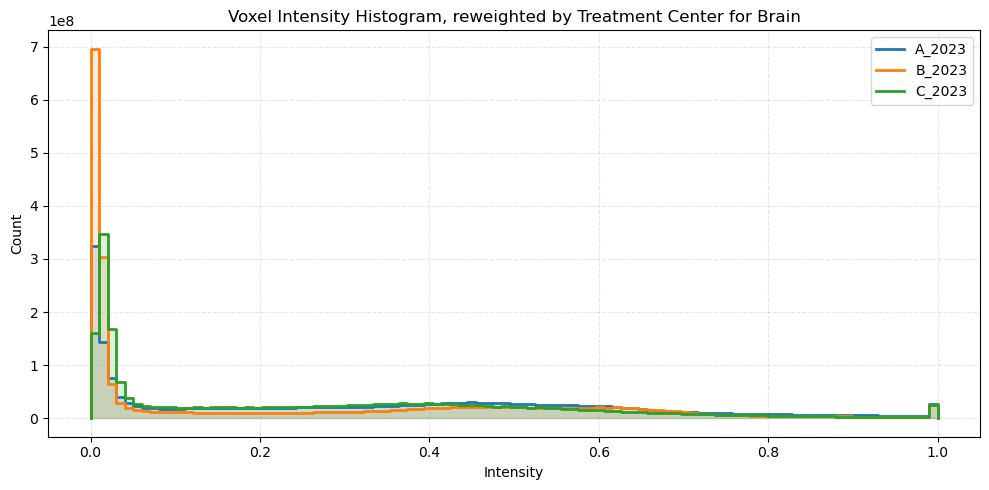

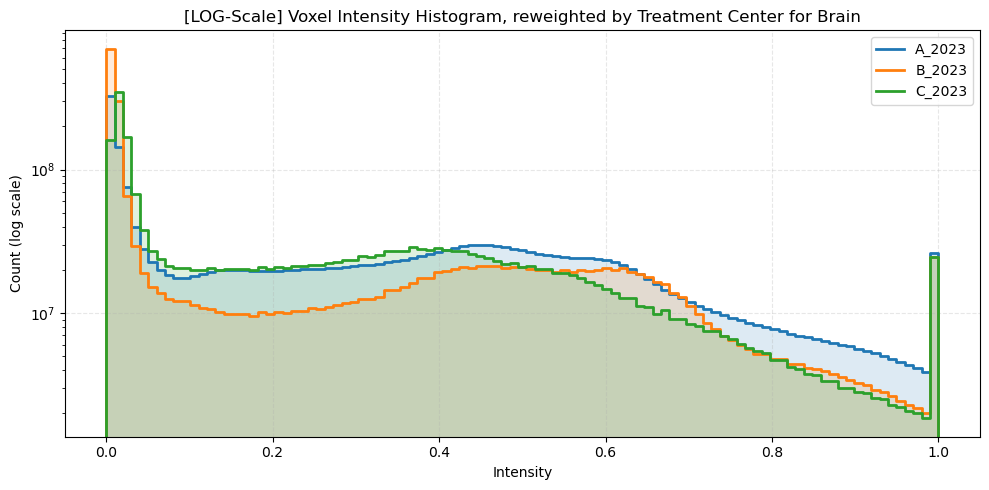

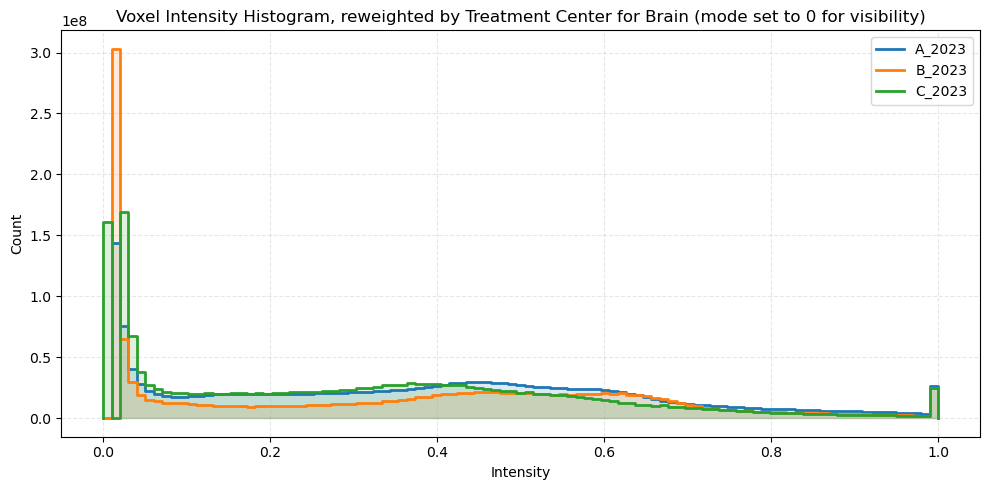

In [9]:
plot_filtered_bodyregion(table, thresholds, "B")

### Head-and-Neck by Treatment Center

    group       p90       p95       p99
0  A_2025  0.779035  0.864488  0.986146
1  C_2025  0.607355  0.719376  0.985468
2  D_2025  0.726828  0.826501  0.985903


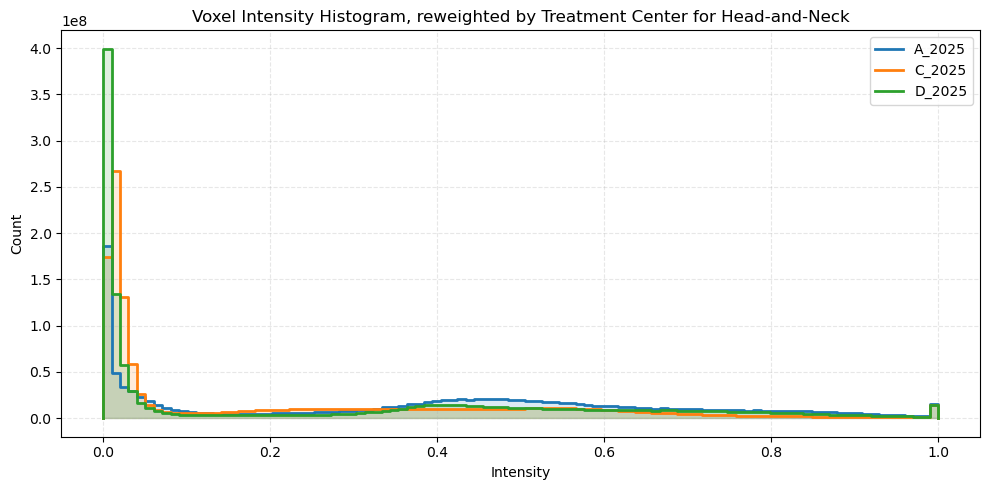

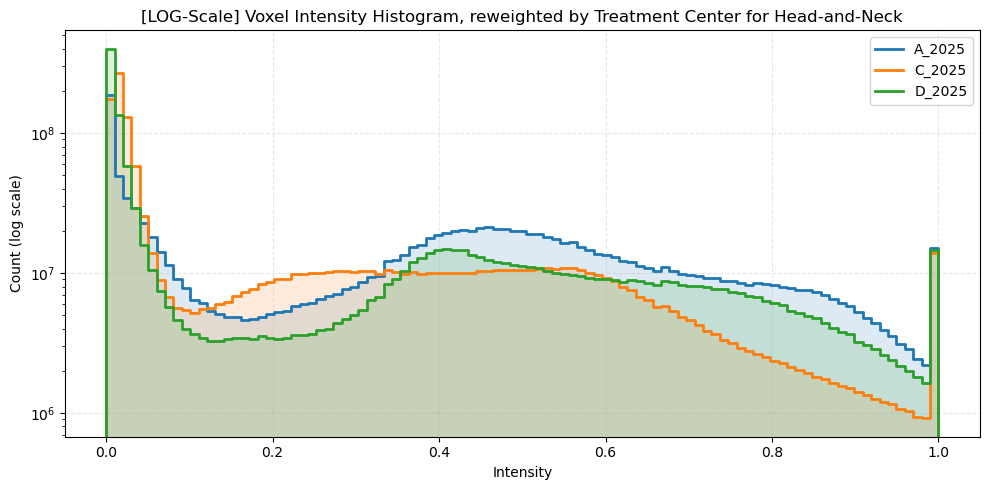

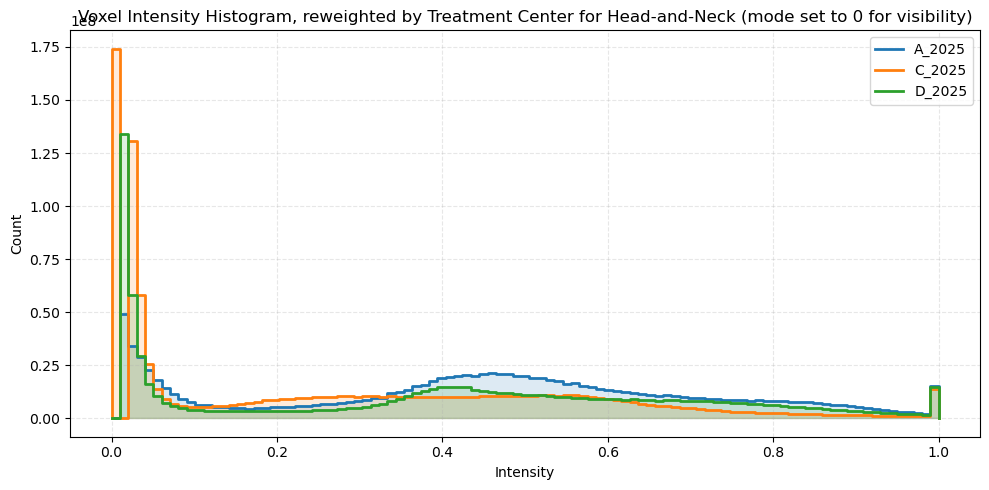

In [10]:
plot_filtered_bodyregion(table, thresholds, "HN")

### Pelvis by Treatment Center

    group       p90       p95       p99
0  A_2023  0.811922  0.883925  0.986446
1  C_2023  0.623640  0.742287  0.985557


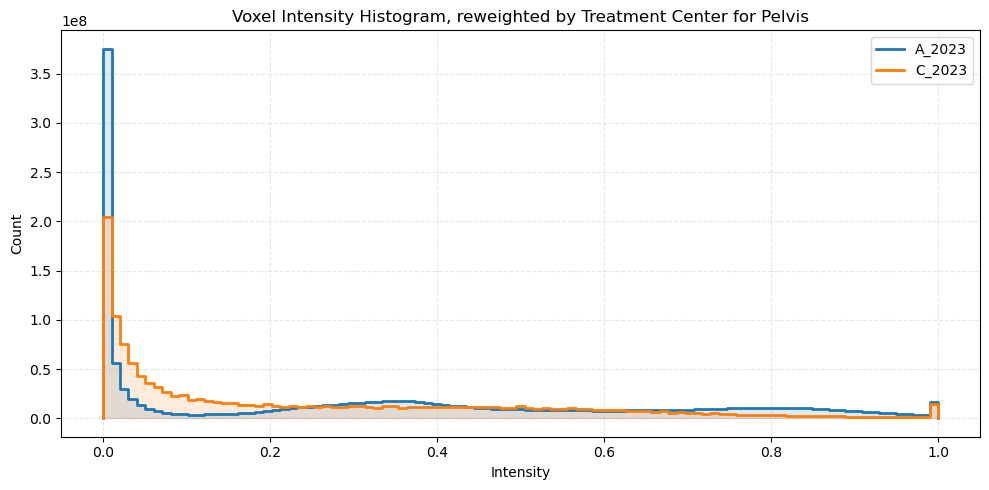

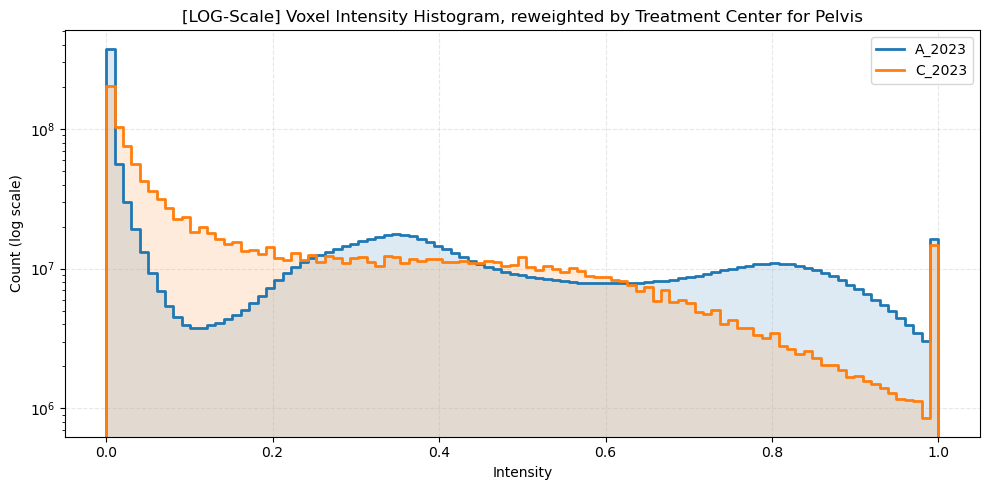

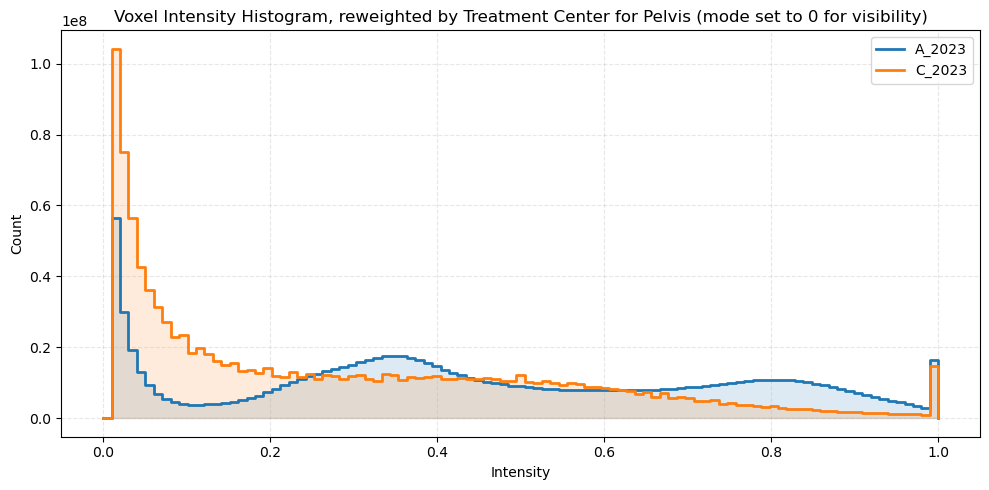

In [11]:
plot_filtered_bodyregion(table, thresholds, "P")

### Thorax by Treatment Center

    group       p90       p95       p99
0  A_2025  0.820862  0.899758  0.986821
1  B_2025  0.522768  0.713240  0.985571


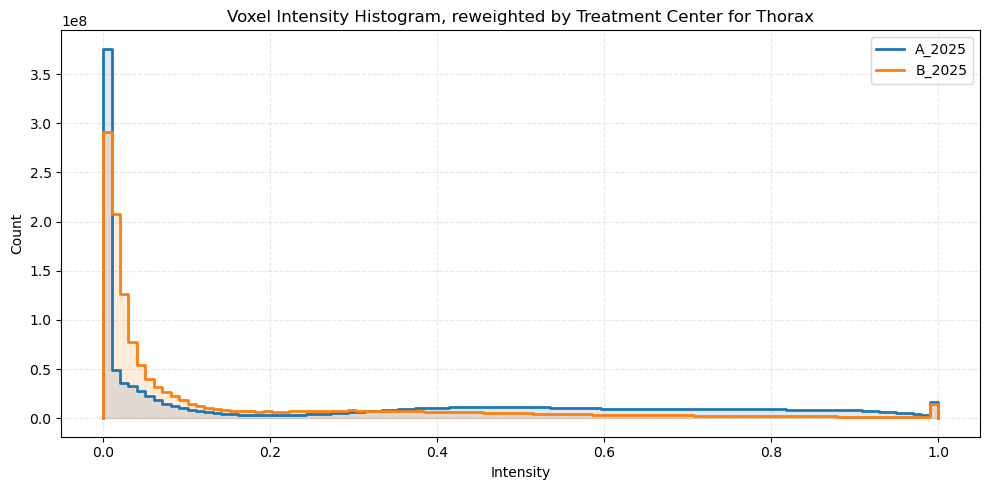

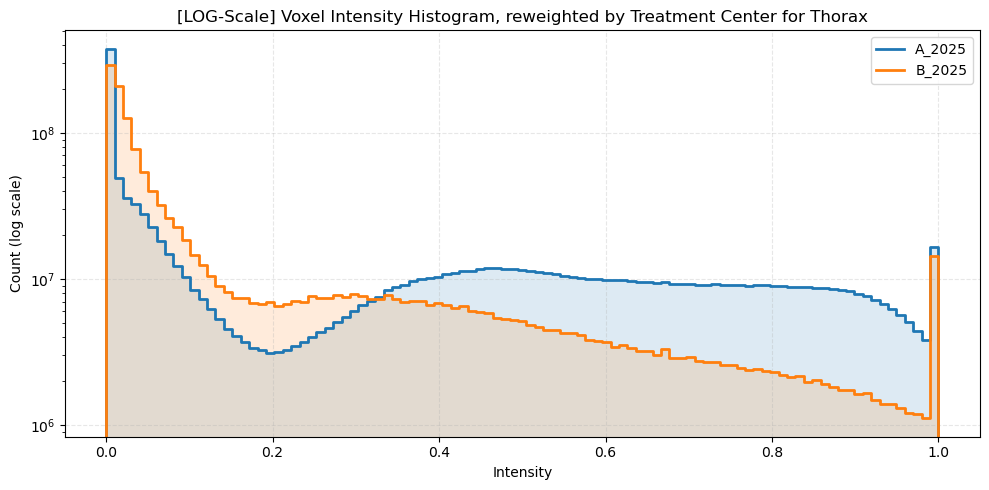

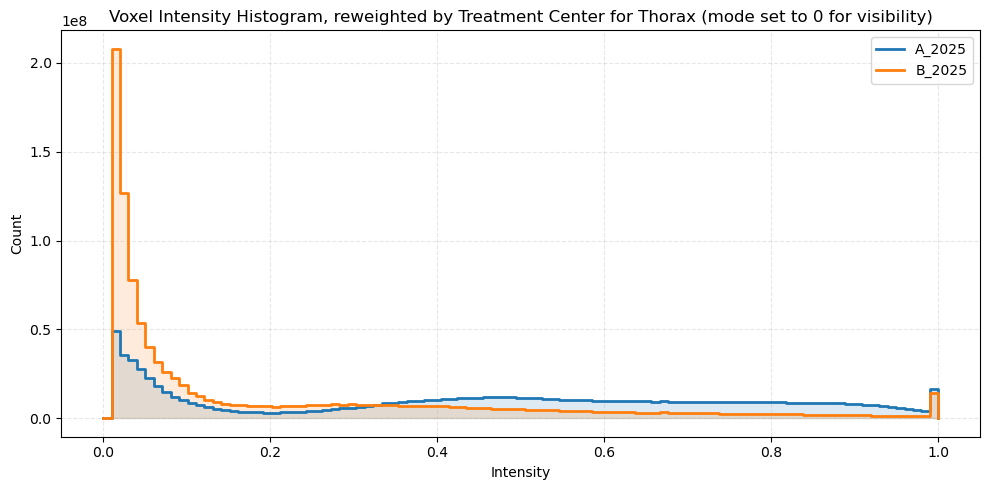

In [12]:
plot_filtered_bodyregion(table, thresholds, "TH")